# Predictive CLTV Dataset Preparation

## Overview

The objective of this stage is to prepare a modelling-ready dataset for predictive Customer Lifetime Value (CLTV) analysis.

The customer-level dataset developed during Week 3 already contains several behavioural and transactional metrics. During this stage, these variables are validated and additional modelling features are engineered to improve the predictive capability of the dataset.

The resulting dataset will serve as the input for predictive CLTV modelling in the next stage of the project.

In [56]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [57]:
# ==========================================
# Project Paths
# ==========================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"
IMAGES = PROJECT_ROOT / "images"
REPORTS = PROJECT_ROOT / "reports"

print("Project directories configured successfully.")

Project directories configured successfully.


In [58]:
import os

print(sorted(os.listdir(PROCESSED_DATA)))

['.gitkeep', 'cltv_model_dataset.csv', 'cltv_predictions.csv', 'cohort_counts.csv', 'cohort_sizes.csv', 'customer_segment_details.csv', 'customer_segments.csv', 'customer_summary.csv', 'dashboard_inventory.csv', 'executive_summary.csv', 'feature_importance.csv', 'online_retail_clean.csv', 'powerbi_data_dictionary.csv', 'prediction_summary.csv', 'retention_matrix.csv', 'segment_metrics.csv', 'top10_cltv_customers.csv', 'top_predicted_customers.csv']


In [59]:
# ==========================================
# Load Customer Summary Dataset
# ==========================================

customer_summary = pd.read_csv(
    PROCESSED_DATA / "customer_summary.csv",
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print("Customer Summary Dataset Loaded Successfully")
print(customer_summary.shape)

customer_summary.head()

Customer Summary Dataset Loaded Successfully
(5878, 12)


,Customer ID,TotalRevenue,TotalOrders,TotalTransactions,TotalProducts,FirstPurchase,LastPurchase,CustomerLifespan,AverageOrderValue,PurchaseFrequency,CustomerAge,HistoricalCLTV
0,12346.0,77556.46,12,34,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,400,6463.038333,6.289384,725,16259412.33
1,12347.0,4921.53,8,222,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,402,615.191250,6.289384,403,1555407.99
2,12348.0,2019.40,5,51,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,362,403.880000,6.289384,437,919536.64
3,12349.0,4428.69,4,175,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,570,1107.172500,6.289384,588,3969156.90
4,12350.0,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,6.289384,309,0.00


In [60]:
# ==========================================
# Dataset Validation
# ==========================================

print("Dataset Shape:", customer_summary.shape)

print("\nColumn Names:")
print(customer_summary.columns.tolist())

print("\nMissing Values:")
print(customer_summary.isnull().sum())

print("\nDataset Information:")
customer_summary.info()

Dataset Shape: (5878, 12)

Column Names:
['Customer ID', 'TotalRevenue', 'TotalOrders', 'TotalTransactions', 'TotalProducts', 'FirstPurchase', 'LastPurchase', 'CustomerLifespan', 'AverageOrderValue', 'PurchaseFrequency', 'CustomerAge', 'HistoricalCLTV']

Missing Values:
Customer ID          0
TotalRevenue         0
TotalOrders          0
TotalTransactions    0
TotalProducts        0
FirstPurchase        0
LastPurchase         0
CustomerLifespan     0
AverageOrderValue    0
PurchaseFrequency    0
CustomerAge          0
HistoricalCLTV       0
dtype: int64

Dataset Information:


<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        5878 non-null   float64       
 1   TotalRevenue       5878 non-null   float64       
 2   TotalOrders        5878 non-null   int64         
 3   TotalTransactions  5878 non-null   int64         
 4   TotalProducts      5878 non-null   int64         
 5   FirstPurchase      5878 non-null   datetime64[us]
 6   LastPurchase       5878 non-null   datetime64[us]
 7   CustomerLifespan   5878 non-null   int64         
 8   AverageOrderValue  5878 non-null   float64       
 9   PurchaseFrequency  5878 non-null   float64       
 10  CustomerAge        5878 non-null   int64         
 11  HistoricalCLTV     5878 non-null   float64       
dtypes: datetime64[us](2), float64(5), int64(5)
memory usage: 551.2 KB


In [61]:
# ==========================================
# Feature Engineering: Customer Recency
# ==========================================

reference_date = customer_summary["LastPurchase"].max()

customer_summary["CustomerRecency"] = (
    reference_date - customer_summary["LastPurchase"]
).dt.days

customer_summary[
    ["LastPurchase", "CustomerRecency"]
].head()

,LastPurchase,CustomerRecency
0,2011-01-18 10:01:00,325
1,2011-12-07 15:52:00,1
2,2011-09-25 13:13:00,74
3,2011-11-21 09:51:00,18
4,2011-02-02 16:01:00,309


In [62]:
# ==========================================
# Feature Engineering: Revenue per Product
# ==========================================

customer_summary["RevenuePerProduct"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalProducts"]
)

customer_summary[
    ["TotalRevenue", "TotalProducts", "RevenuePerProduct"]
].head()

,TotalRevenue,TotalProducts,RevenuePerProduct
0,77556.46,74285,1.044039
1,4921.53,2967,1.658756
2,2019.40,2714,0.744068
3,4428.69,1624,2.727026
4,334.40,197,1.697462


In [63]:
# ==========================================
# Feature Engineering: Revenue per Transaction
# ==========================================

customer_summary["RevenuePerTransaction"] = (
    customer_summary["TotalRevenue"] /
    customer_summary["TotalTransactions"]
)

customer_summary[
    ["TotalRevenue", "TotalTransactions", "RevenuePerTransaction"]
].head()

,TotalRevenue,TotalTransactions,RevenuePerTransaction
0,77556.46,34,2281.072353
1,4921.53,222,22.169054
2,2019.40,51,39.596078
3,4428.69,175,25.306800
4,334.40,17,19.670588


In [64]:
# ==========================================
# Feature Summary
# ==========================================

customer_summary[
    [
        "CustomerRecency",
        "RevenuePerProduct",
        "RevenuePerTransaction"
    ]
].describe().round(2)

,CustomerRecency,RevenuePerProduct,RevenuePerTransaction
count,5878.00,5878.00,5878.00
mean,200.33,7.15,48.30
std,209.34,176.23,780.18
min,0.00,0.12,2.14
25%,25.00,1.43,11.56
50%,95.00,1.83,17.37
75%,379.00,2.35,24.18
max,738.00,10953.50,56157.50


In [65]:
# ==========================================
# Save Predictive CLTV Dataset
# ==========================================

customer_summary.to_csv(
    PROCESSED_DATA / "cltv_model_dataset.csv",
    index=False
)

print("Predictive CLTV dataset saved successfully.")
print(customer_summary.shape)

Predictive CLTV dataset saved successfully.
(5878, 15)


## Feature Engineering Summary

To prepare the dataset for predictive Customer Lifetime Value (CLTV) modelling, additional behavioural features were engineered and validated.

### New Features

- **Customer Recency:** Number of days since the customer's most recent purchase.
- **Revenue per Product:** Average revenue generated per product purchased.
- **Revenue per Transaction:** Average revenue generated per transaction.

The engineered features enhance the modelling dataset by incorporating customer engagement and spending behaviour, creating a richer feature set for predictive analytics. The completed modelling dataset was exported for use in the predictive CLTV modelling stage.

# Predictive Customer Lifetime Value (CLTV) Modelling

## Overview

This stage develops a predictive model capable of estimating Customer Lifetime Value (CLTV) from customer behavioural and transactional characteristics.

The modelling process includes:

- Selecting modelling features
- Preparing training and testing datasets
- Training a regression model
- Evaluating model performance
- Generating predicted CLTV values

The resulting predictions will support customer prioritization and future business intelligence reporting.

In [66]:
# ==========================================
# Machine Learning Libraries
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Machine learning libraries imported successfully.")

Machine learning libraries imported successfully.


In [67]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [68]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [69]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.0


In [70]:
# ==========================================
# Load Modelling Dataset
# ==========================================

df = pd.read_csv(
    PROCESSED_DATA / "cltv_model_dataset.csv",
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print(df.shape)

df.head()

(5878, 15)


,Customer ID,TotalRevenue,TotalOrders,TotalTransactions,TotalProducts,FirstPurchase,LastPurchase,CustomerLifespan,AverageOrderValue,PurchaseFrequency,CustomerAge,HistoricalCLTV,CustomerRecency,RevenuePerProduct,RevenuePerTransaction
0,12346.0,77556.46,12,34,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,400,6463.038333,6.289384,725,16259412.33,325,1.044039,2281.072353
1,12347.0,4921.53,8,222,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,402,615.191250,6.289384,403,1555407.99,1,1.658756,22.169054
2,12348.0,2019.40,5,51,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,362,403.880000,6.289384,437,919536.64,74,0.744068,39.596078
3,12349.0,4428.69,4,175,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,570,1107.172500,6.289384,588,3969156.90,18,2.727026,25.306800
4,12350.0,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,6.289384,309,0.00,309,1.697462,19.670588


In [71]:
# ==========================================
# Feature Selection
# ==========================================

features = [
    "TotalRevenue",
    "TotalOrders",
    "TotalTransactions",
    "TotalProducts",
    "AverageOrderValue",
    "PurchaseFrequency",
    "CustomerAge",
    "CustomerLifespan",
    "CustomerRecency",
    "RevenuePerProduct",
    "RevenuePerTransaction"
]

X = df[features]

y = df["HistoricalCLTV"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (5878, 11)
Target: (5878,)


In [72]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (4702, 11)
Testing Set : (1176, 11)


In [73]:
# ==========================================
# Train Random Forest Model
# ==========================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [74]:
# ==========================================
# Generate Predictions
# ==========================================

predictions = model.predict(X_test)

predictions[:10]

array([ 105252.26745, 1081568.2562 ,  120856.2405 ,   32631.0665 ,
             0.     ,  488154.3703 , 1061672.45065,  857543.16975,
             0.     ,  209589.72025])

In [75]:
# ==========================================
# Model Evaluation
# ==========================================

import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 21,274.17
Mean Squared Error (MSE): 11,946,156,076.28
Root Mean Squared Error (RMSE): 109,298.47
R² Score: 0.9890


In [76]:
import sklearn
print(sklearn.__version__)

1.9.0


In [77]:
print("Training R² :", model.score(X_train, y_train))
print("Testing R²  :", model.score(X_test, y_test))

Training R² : 0.9285086650302486
Testing R²  : 0.9889770848064675


In [78]:
# ==========================================
# Predict CLTV for All Customers
# ==========================================

df["PredictedCLTV"] = model.predict(X)

df[
    [
        "Customer ID",
        "HistoricalCLTV",
        "PredictedCLTV"
    ]
].head()

,Customer ID,HistoricalCLTV,PredictedCLTV
0,12346.0,16259412.33,1.433934e+07
1,12347.0,1555407.99,1.545117e+06
2,12348.0,919536.64,9.112559e+05
3,12349.0,3969156.90,3.896830e+06
4,12350.0,0.00,0.000000e+00


In [79]:
# ==========================================
# Save Prediction Dataset
# ==========================================

df.to_csv(
    PROCESSED_DATA / "cltv_predictions.csv",
    index=False
)

print("Prediction dataset saved successfully.")
print(df.shape)

Prediction dataset saved successfully.
(5878, 16)


# Model Interpretation and Business Insights

## Overview

After developing the predictive Customer Lifetime Value (CLTV) model, the next step is to interpret the model's outputs and translate them into actionable business insights.

This stage evaluates the factors that influence customer lifetime value, compares predicted and actual customer values, identifies high-value customers, and develops recommendations to support customer retention, marketing optimization, and strategic decision-making.

In [80]:
# ==========================================
# Load Prediction Dataset
# ==========================================

predictions_df = pd.read_csv(
    PROCESSED_DATA / "cltv_predictions.csv",
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print(predictions_df.shape)

predictions_df.head()

(5878, 16)


,Customer ID,TotalRevenue,TotalOrders,TotalTransactions,TotalProducts,FirstPurchase,LastPurchase,CustomerLifespan,AverageOrderValue,PurchaseFrequency,CustomerAge,HistoricalCLTV,CustomerRecency,RevenuePerProduct,RevenuePerTransaction,PredictedCLTV
0,12346.0,77556.46,12,34,74285,2009-12-14 08:34:00,2011-01-18 10:01:00,400,6463.038333,6.289384,725,16259412.33,325,1.044039,2281.072353,1.433934e+07
1,12347.0,4921.53,8,222,2967,2010-10-31 14:20:00,2011-12-07 15:52:00,402,615.191250,6.289384,403,1555407.99,1,1.658756,22.169054,1.545117e+06
2,12348.0,2019.40,5,51,2714,2010-09-27 14:59:00,2011-09-25 13:13:00,362,403.880000,6.289384,437,919536.64,74,0.744068,39.596078,9.112559e+05
3,12349.0,4428.69,4,175,1624,2010-04-29 13:20:00,2011-11-21 09:51:00,570,1107.172500,6.289384,588,3969156.90,18,2.727026,25.306800,3.896830e+06
4,12350.0,334.40,1,17,197,2011-02-02 16:01:00,2011-02-02 16:01:00,0,334.400000,6.289384,309,0.00,309,1.697462,19.670588,0.000000e+00


In [81]:
# ==========================================
# Feature Importance
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,AverageOrderValue,0.427567
0,TotalRevenue,0.235892
10,RevenuePerTransaction,0.198715
7,CustomerLifespan,0.113321
3,TotalProducts,0.014899
8,CustomerRecency,0.002089
9,RevenuePerProduct,0.002054
6,CustomerAge,0.001933
1,TotalOrders,0.001811
2,TotalTransactions,0.001720


In [82]:
# ==========================================
# Save Feature Importance
# ==========================================

feature_importance.to_csv(
    PROCESSED_DATA / "feature_importance.csv",
    index=False
)

print("Feature Importance saved successfully.")

Feature Importance saved successfully.


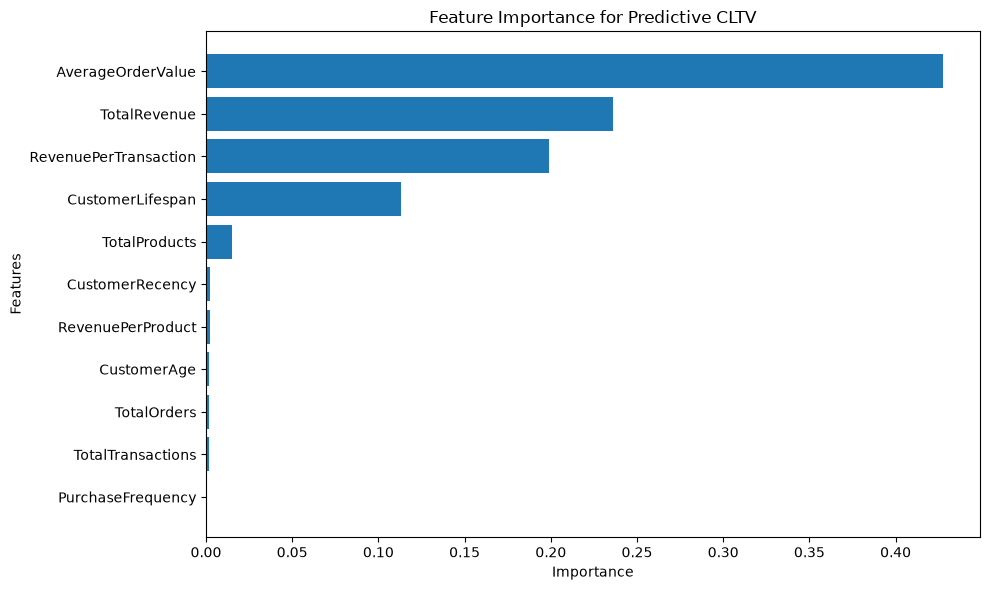

In [83]:
# ==========================================
# Feature Importance Chart
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance for Predictive CLTV")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    IMAGES / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

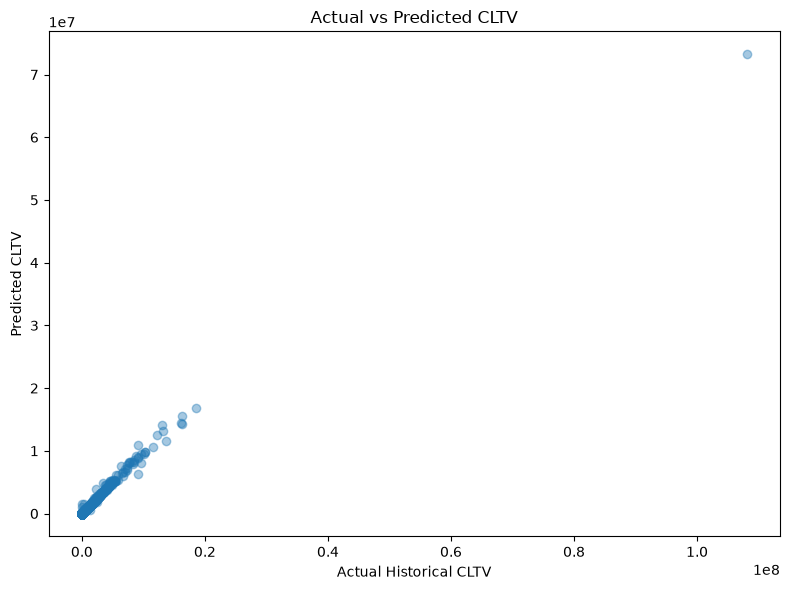

In [84]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(
    predictions_df["HistoricalCLTV"],
    predictions_df["PredictedCLTV"],
    alpha=0.4
)

plt.xlabel("Actual Historical CLTV")
plt.ylabel("Predicted CLTV")
plt.title("Actual vs Predicted CLTV")

plt.tight_layout()

plt.savefig(
    IMAGES / "actual_vs_predicted_cltv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# ==========================================
# Residual Analysis
# ==========================================

predictions_df["Residual"] = (
    predictions_df["HistoricalCLTV"] -
    predictions_df["PredictedCLTV"]
)

predictions_df["Residual"].describe().round(2)

count        5878.00
mean         5615.00
std        464000.68
min      -1789757.35
25%         -2043.62
50%             0.00
75%           898.82
max      34848737.87
Name: Residual, dtype: float64

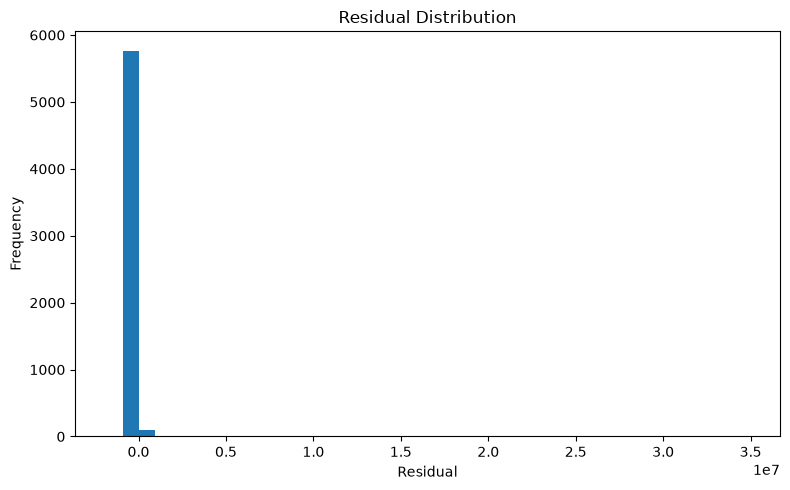

In [86]:
# ==========================================
# Residual Distribution
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(
    predictions_df["Residual"],
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.tight_layout()

plt.savefig(
    IMAGES / "residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
print(predictions_df.columns.tolist())

['Customer ID', 'TotalRevenue', 'TotalOrders', 'TotalTransactions', 'TotalProducts', 'FirstPurchase', 'LastPurchase', 'CustomerLifespan', 'AverageOrderValue', 'PurchaseFrequency', 'CustomerAge', 'HistoricalCLTV', 'CustomerRecency', 'RevenuePerProduct', 'RevenuePerTransaction', 'PredictedCLTV', 'Residual']


In [88]:
# ==========================================
# Load Customer Segments
# ==========================================

segments = pd.read_csv(
    PROCESSED_DATA / "customer_segments.csv"
)

segments.head()

,CustomerSegment,Customers,Percentage
0,Medium Value,2711,46.12
1,Low Value,1697,28.87
2,High Value,1470,25.01


In [89]:
print(segments.columns.tolist())

['CustomerSegment', 'Customers', 'Percentage']


In [90]:
# ==========================================
# Create Customer-Level Segmentation
# ==========================================

customer_segment_details = predictions_df.copy()

q1 = customer_segment_details["HistoricalCLTV"].quantile(0.25)
q3 = customer_segment_details["HistoricalCLTV"].quantile(0.75)

customer_segment_details["CustomerSegment"] = "Medium Value"

customer_segment_details.loc[
    customer_segment_details["HistoricalCLTV"] <= q1,
    "CustomerSegment"
] = "Low Value"

customer_segment_details.loc[
    customer_segment_details["HistoricalCLTV"] >= q3,
    "CustomerSegment"
] = "High Value"

customer_segment_details[
    ["Customer ID", "HistoricalCLTV", "CustomerSegment"]
].head()

,Customer ID,HistoricalCLTV,CustomerSegment
0,12346.0,16259412.33,High Value
1,12347.0,1555407.99,High Value
2,12348.0,919536.64,Medium Value
3,12349.0,3969156.90,High Value
4,12350.0,0.00,Low Value


In [91]:
# ==========================================
# Save Customer Segment Details
# ==========================================

customer_segment_details.to_csv(
    PROCESSED_DATA / "customer_segment_details.csv",
    index=False
)

print("Customer Segment Details saved successfully.")
print(customer_segment_details.shape)

Customer Segment Details saved successfully.
(5878, 18)


In [92]:
# ==========================================
# Customer Segment Summary
# ==========================================

customer_segments = (
    customer_segment_details["CustomerSegment"]
    .value_counts()
    .reset_index()
)

customer_segments.columns = [
    "CustomerSegment",
    "Customers"
]

customer_segments["Percentage"] = (
    customer_segments["Customers"]
    / customer_segments["Customers"].sum()
    * 100
).round(2)

customer_segments

,CustomerSegment,Customers,Percentage
0,Medium Value,2711,46.12
1,Low Value,1697,28.87
2,High Value,1470,25.01


In [93]:
customer_segments.to_csv(
    PROCESSED_DATA / "customer_segments.csv",
    index=False
)

print("Customer Segment Summary saved successfully.")

Customer Segment Summary saved successfully.


In [94]:
top_predicted = (
    customer_segment_details
    .sort_values(
        by="PredictedCLTV",
        ascending=False
    )
    .head(10)
)

top_predicted[
    [
        "Customer ID",
        "PredictedCLTV",
        "HistoricalCLTV",
        "CustomerSegment"
    ]
]

,Customer ID,PredictedCLTV,HistoricalCLTV,CustomerSegment
4061,16446.0,7.322927e+07,1.080780e+08,High Value
5692,18102.0,1.676948e+07,1.859786e+07,High Value
68,12415.0,1.550032e+07,1.632153e+07,High Value
2277,14646.0,1.442623e+07,1.618258e+07,High Value
0,12346.0,1.433934e+07,1.625941e+07,High Value
5050,17450.0,1.404311e+07,1.295027e+07,High Value
5109,17511.0,1.321643e+07,1.324393e+07,High Value
4295,16684.0,1.254572e+07,1.224943e+07,High Value
11,12357.0,1.152457e+07,1.361048e+07,High Value
1789,14156.0,1.098930e+07,9.199538e+06,High Value


In [95]:
# ==========================================
# Prediction Error
# ==========================================

predictions_df["PredictionError"] = (
    predictions_df["HistoricalCLTV"] -
    predictions_df["PredictedCLTV"]
)

predictions_df["PredictionError"].describe().round(2)

count        5878.00
mean         5615.00
std        464000.68
min      -1789757.35
25%         -2043.62
50%             0.00
75%           898.82
max      34848737.87
Name: PredictionError, dtype: float64

In [96]:
# ==========================================
# Percentage Error
# ==========================================

predictions_df["PercentageError"] = (
    abs(predictions_df["PredictionError"])
    / predictions_df["HistoricalCLTV"].replace(0, np.nan)
) * 100

predictions_df["PercentageError"].describe().round(2)

count    4181.00
mean        2.44
std        25.42
min         0.00
25%         0.29
50%         0.68
75%         1.51
max      1511.27
Name: PercentageError, dtype: float64

In [97]:
# ==========================================
# Prediction Summary
# ==========================================

prediction_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "MAE",
        "RMSE",
        "R² Score",
        "Customers Predicted"
    ],
    "Value": [
        "Random Forest",
        round(mae, 2),
        round(rmse, 2),
        round(r2, 4),
        len(predictions_df)
    ]
})

prediction_summary

,Metric,Value
0,Model,Random Forest
1,MAE,21274.17
2,RMSE,109298.47
3,R² Score,0.989
4,Customers Predicted,5878


In [98]:
prediction_summary.to_csv(
    PROCESSED_DATA / "prediction_summary.csv",
    index=False
)

print("Prediction Summary saved successfully.")

Prediction Summary saved successfully.


## Executive Business Insights

The Random Forest regression model demonstrated excellent predictive performance, explaining approximately 98.9% of the variation in customer lifetime value. The average prediction error remained low relative to the range of customer values observed in the dataset.

Error analysis revealed that most customers were predicted with a very small percentage deviation, while larger errors were concentrated among a limited number of exceptionally high-value customers. This behaviour is expected in retail datasets where customer spending is highly skewed.

The model successfully identified the organization's highest-value customers, providing a reliable foundation for customer prioritization, loyalty programme design, retention strategies, and personalized marketing campaigns.

Overall, the predictive model can support data-driven customer relationship management by enabling proactive identification of valuable customers and improving resource allocation across customer segments.

# Power BI Dashboard Preparation

## Overview

This section prepares the processed datasets for Power BI dashboard development.

The objective is to organize analytical outputs into dashboard-ready tables that support executive reporting, customer analytics, cohort retention analysis, and predictive customer lifetime value visualization.

In [99]:
# ==========================================
# Export Top Predicted Customers
# ==========================================

top_predicted_customers = (
    customer_segment_details
    .sort_values(
        by="PredictedCLTV",
        ascending=False
    )
    .head(10)
)

top_predicted_customers.to_csv(
    PROCESSED_DATA / "top_predicted_customers.csv",
    index=False
)

print("Top Predicted Customers exported successfully.")
top_predicted_customers[
    [
        "Customer ID",
        "PredictedCLTV",
        "HistoricalCLTV",
        "CustomerSegment"
    ]
]

Top Predicted Customers exported successfully.


,Customer ID,PredictedCLTV,HistoricalCLTV,CustomerSegment
4061,16446.0,7.322927e+07,1.080780e+08,High Value
5692,18102.0,1.676948e+07,1.859786e+07,High Value
68,12415.0,1.550032e+07,1.632153e+07,High Value
2277,14646.0,1.442623e+07,1.618258e+07,High Value
0,12346.0,1.433934e+07,1.625941e+07,High Value
5050,17450.0,1.404311e+07,1.295027e+07,High Value
5109,17511.0,1.321643e+07,1.324393e+07,High Value
4295,16684.0,1.254572e+07,1.224943e+07,High Value
11,12357.0,1.152457e+07,1.361048e+07,High Value
1789,14156.0,1.098930e+07,9.199538e+06,High Value


In [100]:
# ==========================================
# Dashboard Dataset Verification
# ==========================================

dashboard_files = [
    "executive_summary.csv",
    "customer_segment_details.csv",
    "segment_metrics.csv",
    "retention_matrix.csv",
    "cohort_sizes.csv",
    "feature_importance.csv",
    "prediction_summary.csv",
    "top_predicted_customers.csv"
]

for file in dashboard_files:
    file_path = PROCESSED_DATA / file

    if file_path.exists():
        print(f"✓ {file}")
    else:
        print(f"✗ {file} NOT FOUND")

✓ executive_summary.csv
✓ customer_segment_details.csv
✓ segment_metrics.csv
✓ retention_matrix.csv
✓ cohort_sizes.csv
✓ feature_importance.csv
✓ prediction_summary.csv
✓ top_predicted_customers.csv


In [111]:
# ==========================================
# Load Retention Matrix
# ==========================================

retention_matrix = pd.read_csv(
    PROCESSED_DATA / "retention_matrix.csv",
    index_col=0
)

retention_matrix.head()

,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,37.5,34.3,42.8,39.2,39.0,39.0,35.8,34.0,37.5,...,30.5,26.1,30.2,29.0,27.5,26.2,31.8,30.5,40.9,20.9
2010-01,100.0,21.8,30.2,30.5,27.9,29.2,26.6,23.1,28.9,34.0,...,15.2,21.8,18.8,17.5,18.5,23.6,18.5,22.3,7.4,NaN
2010-02,100.0,30.0,22.6,30.3,25.6,20.9,21.8,28.4,27.5,29.2,...,20.4,18.5,16.8,14.6,23.4,24.8,17.1,6.3,NaN,NaN
2010-03,100.0,21.8,25.9,23.6,22.9,20.0,24.1,29.8,28.9,11.5,...,17.0,17.4,15.8,17.0,20.4,21.3,7.6,NaN,NaN,NaN
2010-04,100.0,23.0,19.9,16.2,18.6,23.0,27.1,26.1,11.3,11.7,...,14.8,14.1,14.1,17.2,21.0,6.5,NaN,NaN,NaN,NaN


In [112]:
# ==========================================
# Export Retention Matrix with Blank Cells
# ==========================================

retention_matrix_export = retention_matrix.fillna("")

retention_matrix_export.to_csv(
    PROCESSED_DATA / "retention_matrix.csv"
)

print("Retention Matrix exported successfully.")

Retention Matrix exported successfully.


In [113]:
# ==========================================
# Dashboard Asset Inventory
# ==========================================

dashboard_inventory = pd.DataFrame({

    "Dataset":[

        "executive_summary.csv",
        "customer_segment_details.csv",
        "segment_metrics.csv",
        "retention_matrix.csv",
        "cohort_sizes.csv",
        "feature_importance.csv",
        "prediction_summary.csv",
        "top_predicted_customers.csv"

    ],

    "Dashboard Use":[

        "Executive KPI Cards",
        "Customer Analytics",
        "Segment Comparison",
        "Retention Heatmap",
        "Cohort Size Matrix",
        "Feature Importance",
        "Model Performance",
        "Top Customers"

    ]

})

dashboard_inventory

,Dataset,Dashboard Use
0,executive_summary.csv,Executive KPI Cards
1,customer_segment_details.csv,Customer Analytics
2,segment_metrics.csv,Segment Comparison
3,retention_matrix.csv,Retention Heatmap
4,cohort_sizes.csv,Cohort Size Matrix
5,feature_importance.csv,Feature Importance
6,prediction_summary.csv,Model Performance
7,top_predicted_customers.csv,Top Customers


In [102]:
dashboard_inventory.to_csv(
    PROCESSED_DATA / "dashboard_inventory.csv",
    index=False
)

print("Dashboard Inventory saved successfully.")

Dashboard Inventory saved successfully.


In [114]:
dashboard_dictionary = pd.DataFrame({

    "Table":[

        "Executive Summary",
        "Customer Segment Details",
        "Segment Metrics",
        "Retention Matrix",
        "Feature Importance",
        "Prediction Summary"

    ],

    "Purpose":[

        "Executive KPIs",
        "Customer Analysis",
        "Segment Analysis",
        "Retention Dashboard",
        "Model Interpretation",
        "ML Performance"

    ]

})

dashboard_dictionary

,Table,Purpose
0,Executive Summary,Executive KPIs
1,Customer Segment Details,Customer Analysis
2,Segment Metrics,Segment Analysis
3,Retention Matrix,Retention Dashboard
4,Feature Importance,Model Interpretation
5,Prediction Summary,ML Performance


In [115]:
dashboard_dictionary.to_csv(
    PROCESSED_DATA / "powerbi_data_dictionary.csv",
    index=False
)

print("Power BI Data Dictionary saved.")

Power BI Data Dictionary saved.


In [116]:
retention_matrix_export = retention_matrix.fillna("")

retention_matrix_export.to_csv(
    PROCESSED_DATA / "retention_matrix_powerbi.csv"
)

print("Power BI Retention Matrix exported successfully.")

Power BI Retention Matrix exported successfully.


In [120]:
import os

powerbi_file = PROCESSED_DATA / "retention_matrix_powerbi.csv"

if powerbi_file.exists():
    os.remove(powerbi_file)
    print("Power BI version deleted successfully.")
else:
    print("File does not exist.")

Power BI version deleted successfully.
